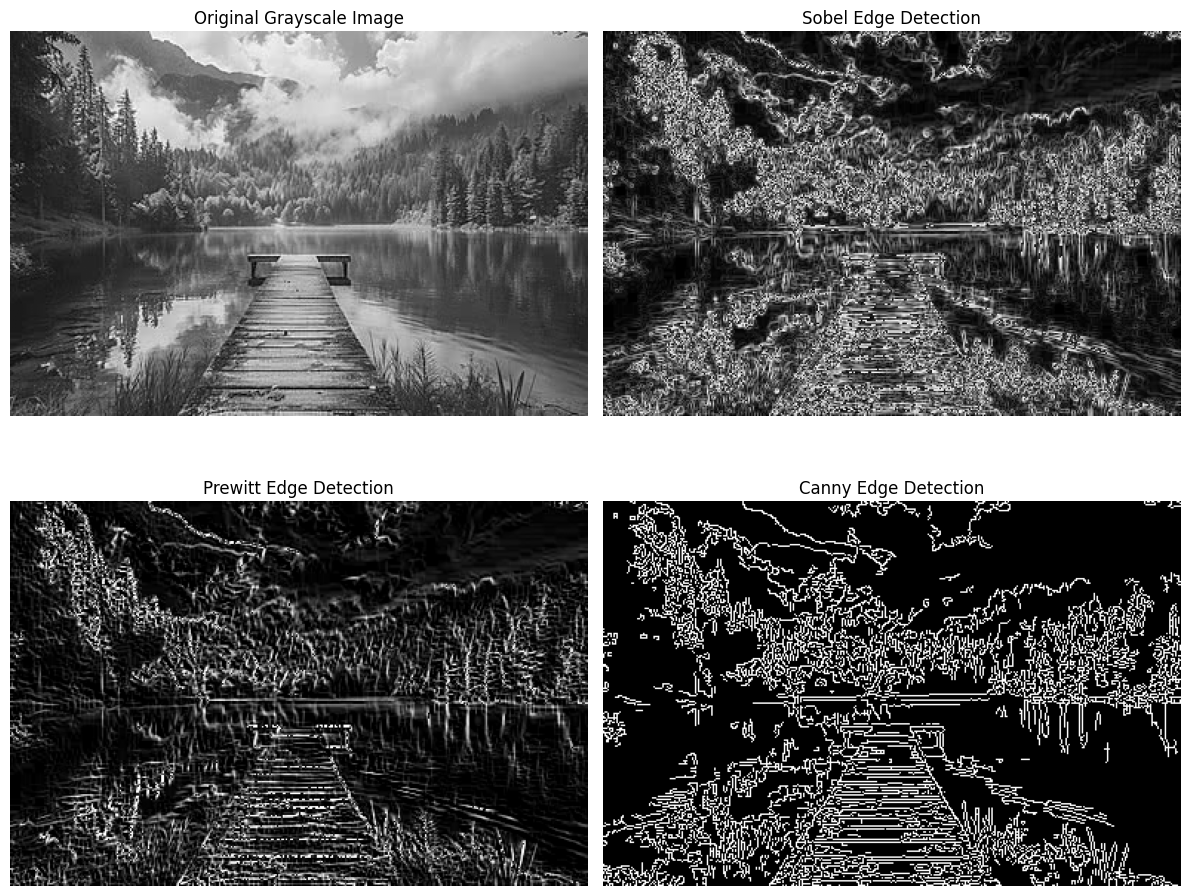

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


# Function to display images
def show_comparison(original, sobel, prewitt, canny):
    plt.figure(figsize=(12, 10))

    # Original Image
    plt.subplot(2, 2, 1)
    plt.imshow(original, cmap='gray')
    plt.title("Original Grayscale Image")
    plt.axis('off')

    # Sobel Edge Detection
    plt.subplot(2, 2, 2)
    plt.imshow(sobel, cmap='gray')
    plt.title("Sobel Edge Detection")
    plt.axis('off')

    # Prewitt Edge Detection
    plt.subplot(2, 2, 3)
    plt.imshow(prewitt, cmap='gray')
    plt.title("Prewitt Edge Detection")
    plt.axis('off')

    # Canny Edge Detection
    plt.subplot(2, 2, 4)
    plt.imshow(canny, cmap='gray')
    plt.title("Canny Edge Detection")
    plt.axis('off')

    plt.tight_layout()
    plt.show()


# Read the image in grayscale mode
img = cv2.imread("/content/drive/MyDrive/Computer Vision/pngtree-new-4k-nature-cb-editing-background-image_16123064.jpg", 0)

if img is None:
    print("Error: Image not found.")
else:

    # -------------------------
    # Sobel Edge Detection
    # -------------------------
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

    # Combine X and Y gradients
    sobel_combined = cv2.magnitude(sobelx, sobely)

    # -------------------------
    # Prewitt Edge Detection
    # -------------------------
    kernelx = np.array([
        [1, 1, 1],
        [0, 0, 0],
        [-1, -1, -1]
    ])

    kernely = np.array([
        [-1, 0, 1],
        [-1, 0, 1],
        [-1, 0, 1]
    ])

    prewittx = cv2.filter2D(img, -1, kernelx)
    prewitty = cv2.filter2D(img, -1, kernely)

    prewitt_combined = prewittx + prewitty

    # -------------------------
    # Canny Edge Detection
    # -------------------------
    canny_edges = cv2.Canny(img, 100, 200)

    # -------------------------
    # Display Results
    # -------------------------
    show_comparison(
        img,
        np.uint8(np.absolute(sobel_combined)),
        prewitt_combined,
        canny_edges
    )



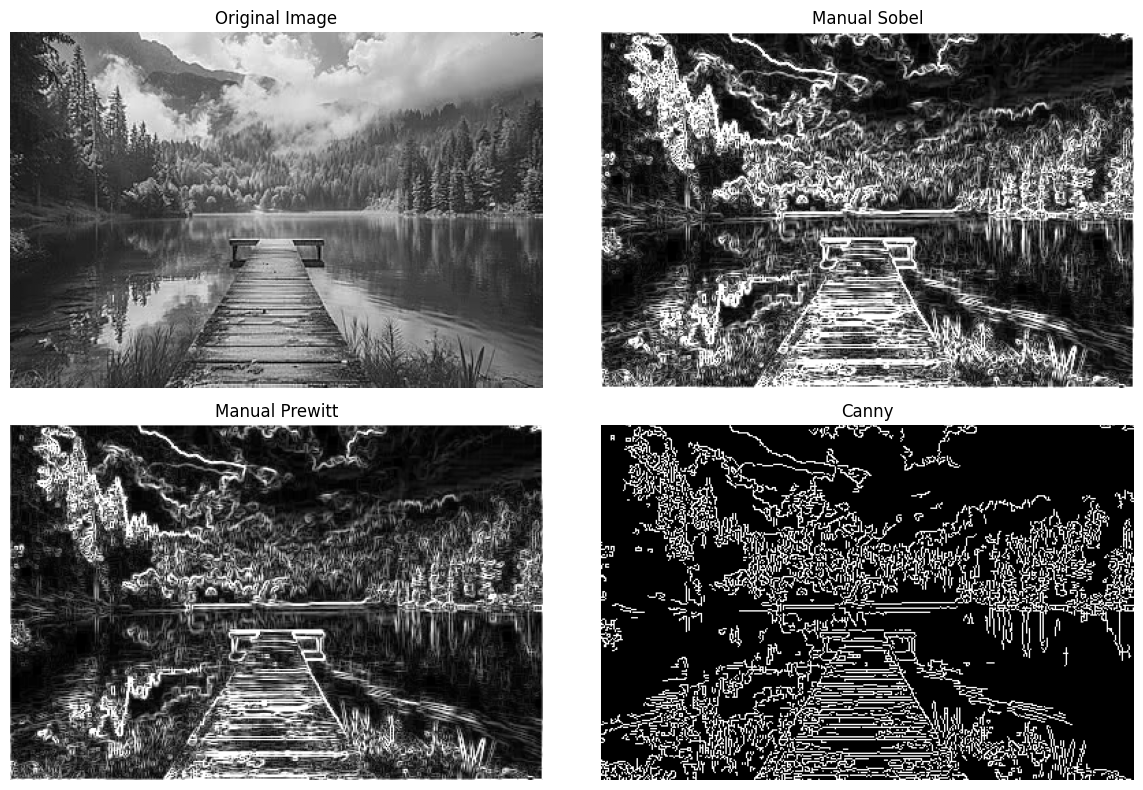

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


# Function for manual convolution
def convolution(image, kernel):
    rows, cols = image.shape
    k = kernel.shape[0]
    pad = k // 2

    padded = np.pad(image, pad, mode='constant')
    output = np.zeros((rows, cols))

    for i in range(rows):
        for j in range(cols):
            region = padded[i:i+k, j:j+k]
            output[i, j] = np.sum(region * kernel)

    return output


# Read image in grayscale
img = cv2.imread("/content/drive/MyDrive/Computer Vision/pngtree-new-4k-nature-cb-editing-background-image_16123064.jpg", 0)

if img is None:
    print("Image not found!")
    exit()

# --------------------
# Sobel Edge Detection
# --------------------
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

sobel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
])

gx = convolution(img, sobel_x)
gy = convolution(img, sobel_y)

sobel_result = np.sqrt(gx**2 + gy**2)
sobel_result = np.uint8(np.clip(sobel_result, 0, 255))

# ----------------------
# Prewitt Edge Detection
# ----------------------
prewitt_x = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])

prewitt_y = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1]
])

px = convolution(img, prewitt_x)
py = convolution(img, prewitt_y)

prewitt_result = np.sqrt(px**2 + py**2)
prewitt_result = np.uint8(np.clip(prewitt_result, 0, 255))

# --------------------
# Canny Edge Detection
# --------------------
# Using OpenCV Canny
canny_result = cv2.Canny(img, 100, 200)

# --------------------
# Display Results
# --------------------
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(sobel_result, cmap='gray')
plt.title("Manual Sobel")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(prewitt_result, cmap='gray')
plt.title("Manual Prewitt")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(canny_result, cmap='gray')
plt.title("Canny")
plt.axis("off")

plt.tight_layout()
plt.show()